# 🧬 Hypothesis Testing for Bioengineering
## A Step-by-Step Tutorial with Visualizations

### By Prabir Kumar Das
---

**What you'll learn in this notebook:**

1. What is Hypothesis Testing?
2. Null & Alternative Hypothesis
3. What is a p-value? (with visual intuition)
4. What is a Confidence Interval?
5. **Z-Test** — One-sample & Two-sample
6. **T-Test** — One-sample, Independent, Paired
7. Real biomedical dataset (Pima Indians Diabetes)
8. Decision framework: When to use which test?

---
**Bioengineering Context:** We apply all tests to realistic scenarios like:
- Blood glucose levels in diabetic patients
- Drug efficacy (before/after treatment)
- Cell growth rates in new culture medium
- Heart rate monitoring (athletes vs sedentary)
- Bone density measurements from implants

## 📦 Setup — Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. What is Hypothesis Testing?

**Hypothesis testing** is a statistical method to make decisions about a **population** from **sample data**.

### Why do we need it in Bioengineering?
Imagine you develop a **new drug** that you believe lowers blood pressure. You test it on 30 patients — their average BP drops by 5 mmHg.  
**The key question:** Is this drop **real** (caused by the drug) or just **random chance**?

### The Two Hypotheses:
| Hypothesis | Symbol | Meaning |
|---|---|---|
| **Null Hypothesis** | H₀ | No effect — "the drug does nothing" |
| **Alternative Hypothesis** | H₁ | There IS an effect — "the drug works" |

We **assume H₀ is true** and check if our data provides enough evidence to **reject it**.

> 💡 Think of it like a court trial: defendant is **innocent until proven guilty**. H₀ = innocent. We need strong evidence to convict (reject H₀).

---
## 2. Understanding p-value

> **p-value** = Probability of observing your data (or more extreme) **IF H₀ were true**

- **Small p-value** (e.g., 0.02) → Data is very unusual under H₀ → **Reject H₀**
- **Large p-value** (e.g., 0.6) → Data is quite likely under H₀ → **Fail to reject H₀**

### Significance Level α
We set a threshold **alpha (α)** before the test. Commonly **α = 0.05**.  
- **p < α** → Reject H₀ (statistically significant)
- **p ≥ α** → Fail to reject H₀

⚠️ **p-value is NOT the probability that H₀ is true!**

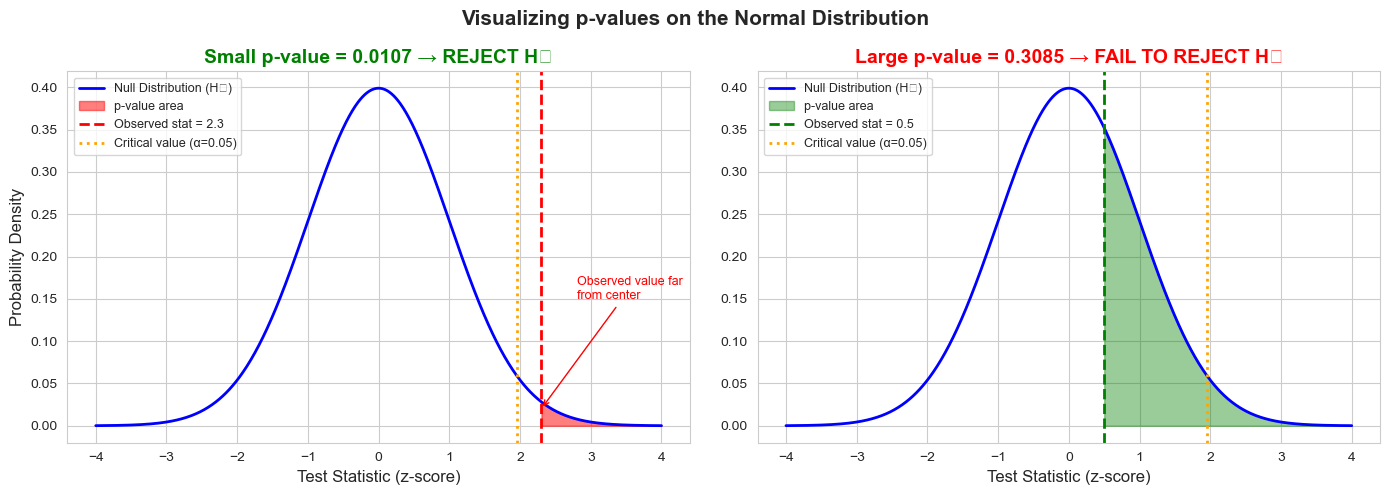

The p-value = shaded area under the curve to the right of the observed statistic.
The FURTHER your result is from center, the SMALLER the p-value!


In [4]:
# Visualizing p-values on the Normal Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

# --- Small p-value ---
ax = axes[0]
ax.plot(x, y, 'b-', linewidth=2, label='Null Distribution (H₀)')
ax.fill_between(x, y, where=(x >= 2.3), color='red', alpha=0.5, label='p-value area')
ax.axvline(x=2.3, color='red', linestyle='--', linewidth=2, label='Observed stat = 2.3')
ax.axvline(x=1.96, color='orange', linestyle=':', linewidth=2, label='Critical value (α=0.05)')
pval = 1 - stats.norm.cdf(2.3)
ax.set_title(f'Small p-value = {pval:.4f} → REJECT H₀', color='green', fontweight='bold')
ax.set_xlabel('Test Statistic (z-score)')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=9)
ax.annotate('Observed value far\nfrom center', xy=(2.3, 0.02), xytext=(2.8, 0.15),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

# --- Large p-value ---
ax = axes[1]
ax.plot(x, y, 'b-', linewidth=2, label='Null Distribution (H₀)')
ax.fill_between(x, y, where=(x >= 0.5), color='green', alpha=0.4, label='p-value area')
ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Observed stat = 0.5')
ax.axvline(x=1.96, color='orange', linestyle=':', linewidth=2, label='Critical value (α=0.05)')
pval2 = 1 - stats.norm.cdf(0.5)
ax.set_title(f'Large p-value = {pval2:.4f} → FAIL TO REJECT H₀', color='red', fontweight='bold')
ax.set_xlabel('Test Statistic (z-score)')
ax.legend(fontsize=9)

plt.suptitle('Visualizing p-values on the Normal Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('The p-value = shaded area under the curve to the right of the observed statistic.')
print('The FURTHER your result is from center, the SMALLER the p-value!')

---
## 3. Confidence Intervals

A **confidence interval (CI)** gives a **range of plausible values** for the true population mean.

> A **95% CI** means: if we repeated the experiment 100 times, 95 of those intervals would contain the true mean.

### Formula:
$$CI = \bar{x} \pm z^* \times \frac{\sigma}{\sqrt{n}}$$

- $\bar{x}$ = sample mean
- $z^*$ = 1.96 for 95% CI
- $\sigma$ = std deviation, $n$ = sample size

**Connection to hypothesis testing:**  
If the null value falls **outside** the CI → Reject H₀

In [6]:
# Confidence Intervals — Blood Glucose Example
# H₀: Normal fasting blood glucose = 90 mg/dL

patient_glucose = np.array([105, 98, 112, 103, 95, 107, 110, 99, 108, 101])
n = len(patient_glucose)
x_bar = np.mean(patient_glucose)
s = np.std(patient_glucose, ddof=1)   # ddof=1 for sample std
se = s / np.sqrt(n)

# 95% CI using t-distribution (small sample, σ unknown)
t_critical = stats.t.ppf(0.975, df=n-1)
ci_lower = x_bar - t_critical * se
ci_upper = x_bar + t_critical * se

print('Blood Glucose Analysis')
print(f'Data: {patient_glucose}')
print(f'Sample mean:  {x_bar:.2f} mg/dL')
print(f'Std dev:      {s:.2f} mg/dL')
print(f'95% CI:       ({ci_lower:.2f}, {ci_upper:.2f})')
print(f'H₀ value (90) in CI? {ci_lower <= 90 <= ci_upper}')
if not (ci_lower <= 90 <= ci_upper):
    print('90 is OUTSIDE the CI → Reject H₀!')

Blood Glucose Analysis
Data: [105  98 112 103  95 107 110  99 108 101]
Sample mean:  103.80 mg/dL
Std dev:      5.55 mg/dL
95% CI:       (99.83, 107.77)
H₀ value (90) in CI? False
90 is OUTSIDE the CI → Reject H₀!


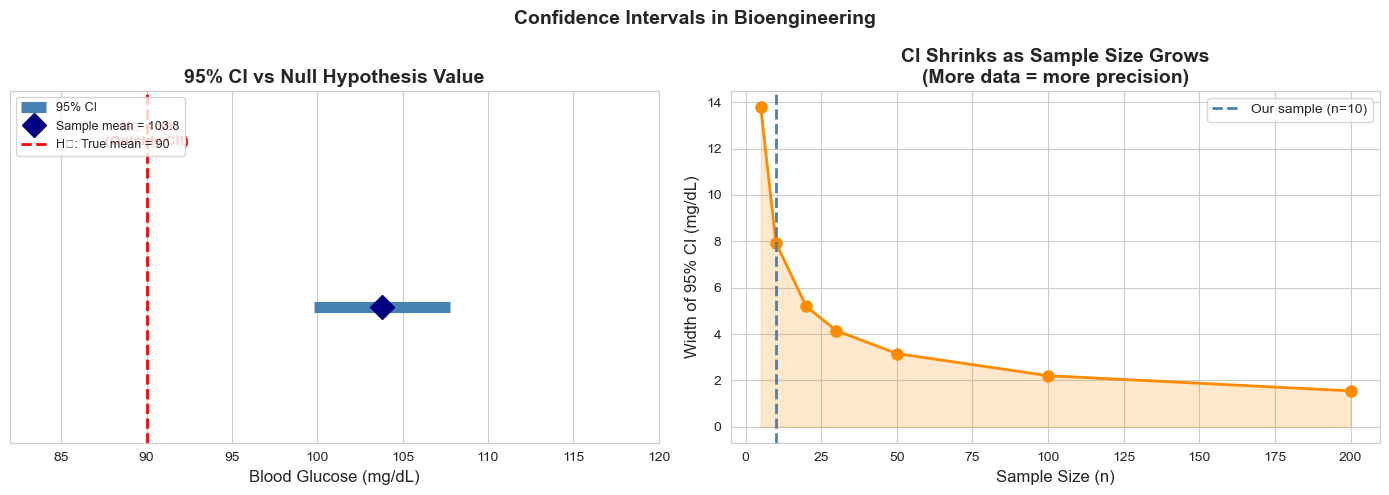

In [8]:
# Visualization: Confidence Interval Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CI on a number line
ax = axes[0]
ax.hlines(1, ci_lower, ci_upper, colors='steelblue', linewidth=8, label='95% CI')
ax.plot(x_bar, 1, 'D', color='navy', markersize=12, label=f'Sample mean = {x_bar:.1f}', zorder=3)
ax.axvline(90, color='red', linestyle='--', linewidth=2, label='H₀: True mean = 90')
ax.set_xlim(82, 120)
ax.set_ylim(0.5, 1.8)
ax.set_yticks([])
ax.set_xlabel('Blood Glucose (mg/dL)')
ax.set_title('95% CI vs Null Hypothesis Value', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.text(90, 1.6, 'H₀ = 90\n(Outside CI!)', ha='center', color='red', fontsize=10, fontweight='bold')

# CI width vs sample size
ax = axes[1]
sample_sizes = [5, 10, 20, 30, 50, 100, 200]
ci_widths = [2 * stats.t.ppf(0.975, df=n_s-1) * (s / np.sqrt(n_s)) for n_s in sample_sizes]
ax.plot(sample_sizes, ci_widths, 'o-', color='darkorange', linewidth=2, markersize=8)
ax.fill_between(sample_sizes, ci_widths, alpha=0.2, color='darkorange')
ax.axvline(10, color='steelblue', linestyle='--', label='Our sample (n=10)', linewidth=2)
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Width of 95% CI (mg/dL)')
ax.set_title('CI Shrinks as Sample Size Grows\n(More data = more precision)', fontweight='bold')
ax.legend()

plt.suptitle('Confidence Intervals in Bioengineering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Z-Test

### When to use:
- Population standard deviation **σ is KNOWN**
- Sample size is **large (n ≥ 30)**

### Formula:
$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

The z-statistic = **how many standard errors** the sample mean is from the null hypothesis mean.

---
### 4.1 One-Sample Z-Test

**🦴 Bone Density Implant Study:**  
- Claimed mean: **μ = 1.05 g/cm²**
- Researcher measures 50 patients, gets x̄ = 1.02 g/cm²
- Known σ = 0.08 g/cm²
- H₀: μ = 1.05 | H₁: μ ≠ 1.05 | α = 0.05

In [10]:
# ONE-SAMPLE Z-TEST — Bone Density

np.random.seed(42)
n = 50
sigma = 0.08      # KNOWN population std dev
mu_0 = 1.05       # Null hypothesis mean

# Generate synthetic data centered at 1.02 (true mean differs from claim)
bone_density = np.random.normal(loc=1.02, scale=sigma, size=n)
x_bar = np.mean(bone_density)

# Step 1: Compute Standard Error
se = sigma / np.sqrt(n)

# Step 2: Compute Z-statistic
z_stat = (x_bar - mu_0) / se

# Step 3: Compute p-value (two-tailed)
p_value_z1 = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Step 4: Compute 95% CI
z_crit = 1.96
ci_low_z1 = x_bar - z_crit * se
ci_high_z1 = x_bar + z_crit * se

print('ONE-SAMPLE Z-TEST: Bone Density Implant')
print('='*50)
print(f'H₀: μ = {mu_0} g/cm²')
print(f'H₁: μ ≠ {mu_0} g/cm²  (two-tailed)')
print()
print(f'n={n}, x̄={x_bar:.4f}, σ={sigma}, SE={se:.4f}')
print()
print(f'Z = (x̄ - μ₀) / SE = ({x_bar:.4f} - {mu_0}) / {se:.4f}')
print(f'Z = {z_stat:.4f}')
print(f'p-value (two-tailed) = {p_value_z1:.4f}')
print(f'95% CI = ({ci_low_z1:.4f}, {ci_high_z1:.4f})')
print()
if p_value_z1 < 0.05:
    print(f'p={p_value_z1:.4f} < 0.05 → REJECT H₀')
    print('Bone density is significantly different from claimed 1.05 g/cm²')
else:
    print(f'p={p_value_z1:.4f} >= 0.05 → FAIL TO REJECT H₀')

ONE-SAMPLE Z-TEST: Bone Density Implant
H₀: μ = 1.05 g/cm²
H₁: μ ≠ 1.05 g/cm²  (two-tailed)

n=50, x̄=1.0020, σ=0.08, SE=0.0113

Z = (x̄ - μ₀) / SE = (1.0020 - 1.05) / 0.0113
Z = -4.2460
p-value (two-tailed) = 0.0000
95% CI = (0.9798, 1.0241)

p=0.0000 < 0.05 → REJECT H₀
Bone density is significantly different from claimed 1.05 g/cm²


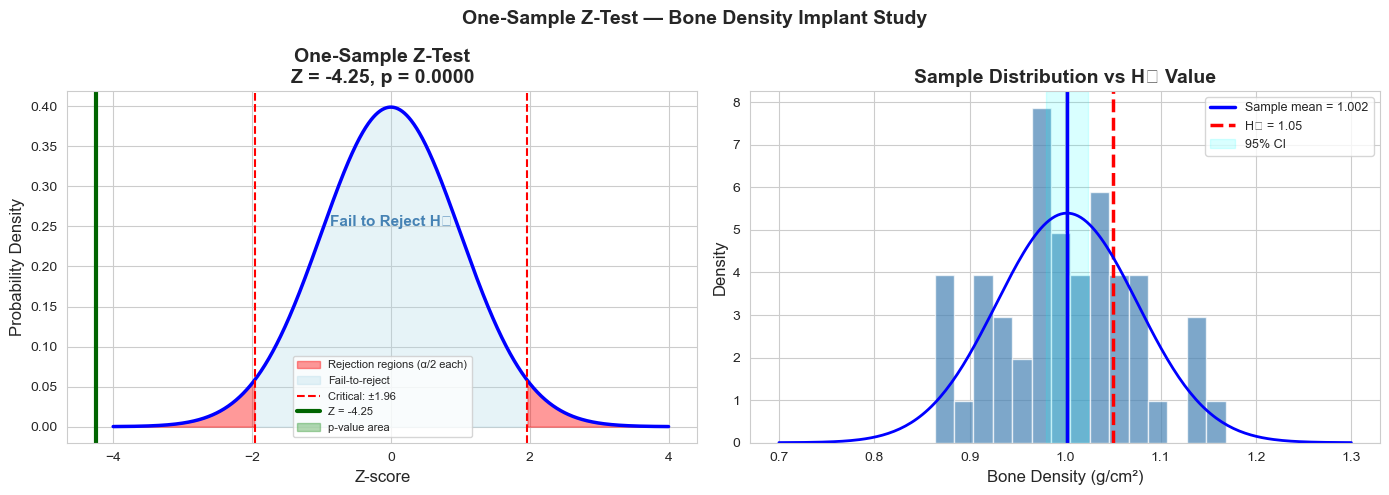

In [12]:
# Visualization: One-Sample Z-Test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Z-distribution with rejection regions
ax = axes[0]
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

ax.plot(x, y, 'b-', linewidth=2.5)
ax.fill_between(x, y, where=(x <= -1.96), color='red', alpha=0.4, label='Rejection regions (α/2 each)')
ax.fill_between(x, y, where=(x >= 1.96), color='red', alpha=0.4)
ax.fill_between(x, y, where=(x >= -1.96) & (x <= 1.96), color='lightblue', alpha=0.3, label='Fail-to-reject')
ax.axvline(-1.96, color='red', linestyle='--', linewidth=1.5)
ax.axvline(1.96, color='red', linestyle='--', linewidth=1.5, label='Critical: ±1.96')
ax.axvline(z_stat, color='darkgreen', linestyle='-', linewidth=3, label=f'Z = {z_stat:.2f}')
ax.fill_between(x, y, where=(x <= z_stat), color='green', alpha=0.3, label=f'p-value area')
ax.fill_between(x, y, where=(x >= abs(z_stat)), color='green', alpha=0.3)

ax.set_xlabel('Z-score')
ax.set_ylabel('Probability Density')
ax.set_title(f'One-Sample Z-Test\nZ = {z_stat:.2f}, p = {p_value_z1:.4f}', fontweight='bold')
ax.legend(fontsize=8)
ax.text(0, 0.25, 'Fail to Reject H₀', ha='center', fontsize=11, color='steelblue', fontweight='bold')

# Sample data with CI
ax = axes[1]
ax.hist(bone_density, bins=15, color='steelblue', edgecolor='white', alpha=0.7, density=True)
ax.axvline(x_bar, color='blue', linewidth=2.5, label=f'Sample mean = {x_bar:.3f}')
ax.axvline(mu_0, color='red', linewidth=2.5, linestyle='--', label=f'H₀ = {mu_0}')
ax.axvspan(ci_low_z1, ci_high_z1, alpha=0.15, color='cyan', label=f'95% CI')
x_r = np.linspace(0.7, 1.3, 200)
ax.plot(x_r, stats.norm.pdf(x_r, x_bar, np.std(bone_density)), 'b-', linewidth=2)
ax.set_xlabel('Bone Density (g/cm²)')
ax.set_ylabel('Density')
ax.set_title('Sample Distribution vs H₀ Value', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('One-Sample Z-Test — Bone Density Implant Study', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Two-Sample Z-Test

Compare **means of two independent groups** when σ is known and n is large.

$$z = \frac{(\bar{x}_1 - \bar{x}_2)}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}}$$

**🫀 Heart Rate Study:**  
- Group A: Athletes (n=50, σ=10 bpm)
- Group B: Sedentary (n=50, σ=12 bpm)
- H₀: μ_athletes = μ_sedentary | H₁: μ_athletes ≠ μ_sedentary

In [14]:
# TWO-SAMPLE Z-TEST — Heart Rate

np.random.seed(7)
n1, n2 = 50, 50
sigma1, sigma2 = 10, 12

group_athletes = np.random.normal(loc=62, scale=sigma1, size=n1)
group_sedentary = np.random.normal(loc=75, scale=sigma2, size=n2)

x_bar1 = np.mean(group_athletes)
x_bar2 = np.mean(group_sedentary)

# Standard Error of the difference
se_diff = np.sqrt((sigma1**2 / n1) + (sigma2**2 / n2))

# Z-statistic
z_stat_2 = (x_bar1 - x_bar2) / se_diff

# Two-tailed p-value
p_value_z2 = 2 * (1 - stats.norm.cdf(abs(z_stat_2)))

# 95% CI for the difference in means
diff = x_bar1 - x_bar2
ci_low_z2 = diff - 1.96 * se_diff
ci_high_z2 = diff + 1.96 * se_diff

print('TWO-SAMPLE Z-TEST: Heart Rate — Athletes vs Sedentary')
print('='*55)
print(f'Athletes:   mean={x_bar1:.2f} bpm, σ={sigma1}, n={n1}')
print(f'Sedentary:  mean={x_bar2:.2f} bpm, σ={sigma2}, n={n2}')
print()
print(f'Difference in means:  {diff:.2f} bpm')
print(f'SE of difference:     {se_diff:.4f}')
print(f'Z = ({x_bar1:.2f} - {x_bar2:.2f}) / {se_diff:.4f} = {z_stat_2:.4f}')
print(f'p-value (two-tailed): {p_value_z2:.6f}')
print(f'95% CI for diff:      ({ci_low_z2:.2f}, {ci_high_z2:.2f})')
print()
if p_value_z2 < 0.05:
    print('REJECT H₀ — Significant difference in heart rates!')

TWO-SAMPLE Z-TEST: Heart Rate — Athletes vs Sedentary
Athletes:   mean=61.07 bpm, σ=10, n=50
Sedentary:  mean=76.41 bpm, σ=12, n=50

Difference in means:  -15.34 bpm
SE of difference:     2.2091
Z = (61.07 - 76.41) / 2.2091 = -6.9460
p-value (two-tailed): 0.000000
95% CI for diff:      (-19.67, -11.01)

REJECT H₀ — Significant difference in heart rates!


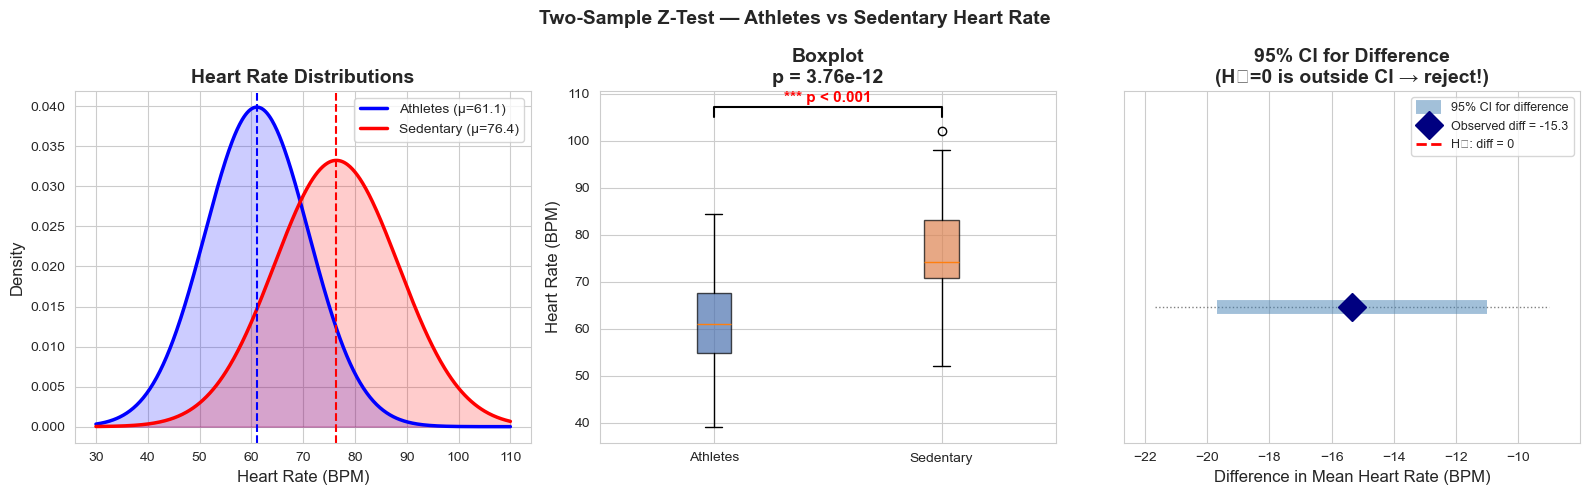

In [16]:
# Visualization: Two-Sample Z-Test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overlapping distributions
ax = axes[0]
x_r = np.linspace(30, 110, 500)
ax.plot(x_r, stats.norm.pdf(x_r, x_bar1, sigma1), 'b-', linewidth=2.5, label=f'Athletes (μ={x_bar1:.1f})')
ax.plot(x_r, stats.norm.pdf(x_r, x_bar2, sigma2), 'r-', linewidth=2.5, label=f'Sedentary (μ={x_bar2:.1f})')
ax.fill_between(x_r, stats.norm.pdf(x_r, x_bar1, sigma1), alpha=0.2, color='blue')
ax.fill_between(x_r, stats.norm.pdf(x_r, x_bar2, sigma2), alpha=0.2, color='red')
ax.axvline(x_bar1, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(x_bar2, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Heart Rate (BPM)')
ax.set_ylabel('Density')
ax.set_title('Heart Rate Distributions', fontweight='bold')
ax.legend()

# Box plots
ax = axes[1]
bp = ax.boxplot([group_athletes, group_sedentary], labels=['Athletes', 'Sedentary'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('#4C72B0'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#DD8452'); bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Heart Rate (BPM)')
ax.set_title(f'Boxplot\np = {p_value_z2:.2e}', fontweight='bold')
y_max = max(group_athletes.max(), group_sedentary.max()) + 3
ax.plot([1, 1, 2, 2], [y_max, y_max+2, y_max+2, y_max], 'k-', linewidth=1.5)
ax.text(1.5, y_max + 3, '*** p < 0.001', ha='center', fontsize=11, color='red', fontweight='bold')

# CI for difference
ax = axes[2]
ax.hlines(0, ci_low_z2 - 2, ci_high_z2 + 2, colors='gray', linewidth=1, linestyle=':')
ax.hlines(0, ci_low_z2, ci_high_z2, colors='steelblue', linewidth=10, alpha=0.5, label='95% CI for difference')
ax.plot(diff, 0, 'D', color='navy', markersize=14, label=f'Observed diff = {diff:.1f}')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H₀: diff = 0')
ax.set_xlim(ci_low_z2 - 3, ci_high_z2 + 3)
ax.set_ylim(-0.5, 0.8)
ax.set_yticks([])
ax.set_xlabel('Difference in Mean Heart Rate (BPM)')
ax.set_title('95% CI for Difference\n(H₀=0 is outside CI → reject!)', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Two-Sample Z-Test — Athletes vs Sedentary Heart Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. T-Test

### When to use:
- Population σ is **UNKNOWN** (most real-world cases!)
- Use **sample std (s)** instead
- Compare to the **t-distribution** (heavier tails than normal)

### Three types:
| Type | When to Use |
|---|---|
| **One-sample t-test** | Compare sample to a known reference value |
| **Independent t-test** | Compare two different groups |
| **Paired t-test** | Before/after measurements on same subjects |

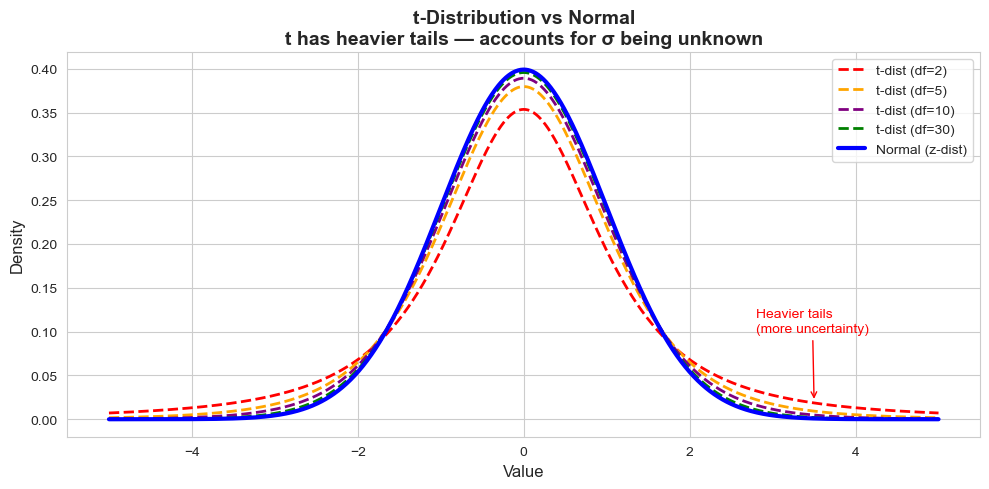

As df (= n-1) increases, t-distribution → Normal distribution
This is why Z-test and T-test give similar results for large samples!


In [18]:
# t-distribution vs Normal Distribution

fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-5, 5, 1000)

dfs = [2, 5, 10, 30]
colors_t = ['red', 'orange', 'purple', 'green']
for df, color in zip(dfs, colors_t):
    ax.plot(x, stats.t.pdf(x, df), color=color, linewidth=2, linestyle='--', label=f't-dist (df={df})')

ax.plot(x, stats.norm.pdf(x), 'b-', linewidth=3, label='Normal (z-dist)')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title('t-Distribution vs Normal\nt has heavier tails — accounts for σ being unknown', fontweight='bold')
ax.legend()
ax.annotate('Heavier tails\n(more uncertainty)', xy=(3.5, 0.02), xytext=(2.8, 0.1),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)
plt.tight_layout()
plt.show()

print('As df (= n-1) increases, t-distribution → Normal distribution')
print('This is why Z-test and T-test give similar results for large samples!')

### 5.1 One-Sample T-Test

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

Same formula as Z-test but uses **sample s** and compares to **t-distribution with df = n-1**.

**🧫 Cell Growth Rate Study:**  
Standard growth rate = 0.45 OD/hour. Testing a new culture medium on 15 samples.  
Is the new medium significantly different?

In [20]:
# ONE-SAMPLE T-TEST — Cell Growth Rate

growth_rates = np.array([0.51, 0.48, 0.53, 0.49, 0.55, 0.47, 0.52,
                         0.50, 0.54, 0.46, 0.53, 0.49, 0.56, 0.51, 0.48])
mu_0 = 0.45    # Standard growth rate (H₀)

n = len(growth_rates)
x_bar = np.mean(growth_rates)
s = np.std(growth_rates, ddof=1)   # ddof=1 is IMPORTANT for sample std!
se = s / np.sqrt(n)
df = n - 1

# T-statistic
t_stat_1 = (x_bar - mu_0) / se

# p-value (two-tailed)
p_value_t1 = 2 * (1 - stats.t.cdf(abs(t_stat_1), df=df))

# 95% CI
t_crit_1 = stats.t.ppf(0.975, df=df)
ci_low_t1 = x_bar - t_crit_1 * se
ci_high_t1 = x_bar + t_crit_1 * se

# Verify with scipy
t_sp, p_sp = stats.ttest_1samp(growth_rates, popmean=mu_0)

print('ONE-SAMPLE T-TEST: Cell Growth Rate')
print('='*50)
print(f'Data: {growth_rates}')
print(f'H₀: μ = {mu_0} OD/hour | H₁: μ ≠ {mu_0} (two-tailed)')
print()
print(f'n={n}, x̄={x_bar:.4f}, s={s:.4f}, SE={se:.4f}, df={df}')
print()
print(f't = (x̄ - μ₀) / SE = ({x_bar:.4f} - {mu_0}) / {se:.4f} = {t_stat_1:.4f}')
print(f'p-value: {p_value_t1:.6f}')
print(f'95% CI: ({ci_low_t1:.4f}, {ci_high_t1:.4f})')
print()
print(f'Scipy verification: t={t_sp:.4f}, p={p_sp:.6f}  [matches!]')
print()
if p_value_t1 < 0.05:
    print('REJECT H₀ — New medium produces significantly higher growth rates!')

ONE-SAMPLE T-TEST: Cell Growth Rate
Data: [0.51 0.48 0.53 0.49 0.55 0.47 0.52 0.5  0.54 0.46 0.53 0.49 0.56 0.51
 0.48]
H₀: μ = 0.45 OD/hour | H₁: μ ≠ 0.45 (two-tailed)

n=15, x̄=0.5080, s=0.0300, SE=0.0078, df=14

t = (x̄ - μ₀) / SE = (0.5080 - 0.45) / 0.0078 = 7.4759
p-value: 0.000003
95% CI: (0.4914, 0.5246)

Scipy verification: t=7.4759, p=0.000003  [matches!]

REJECT H₀ — New medium produces significantly higher growth rates!


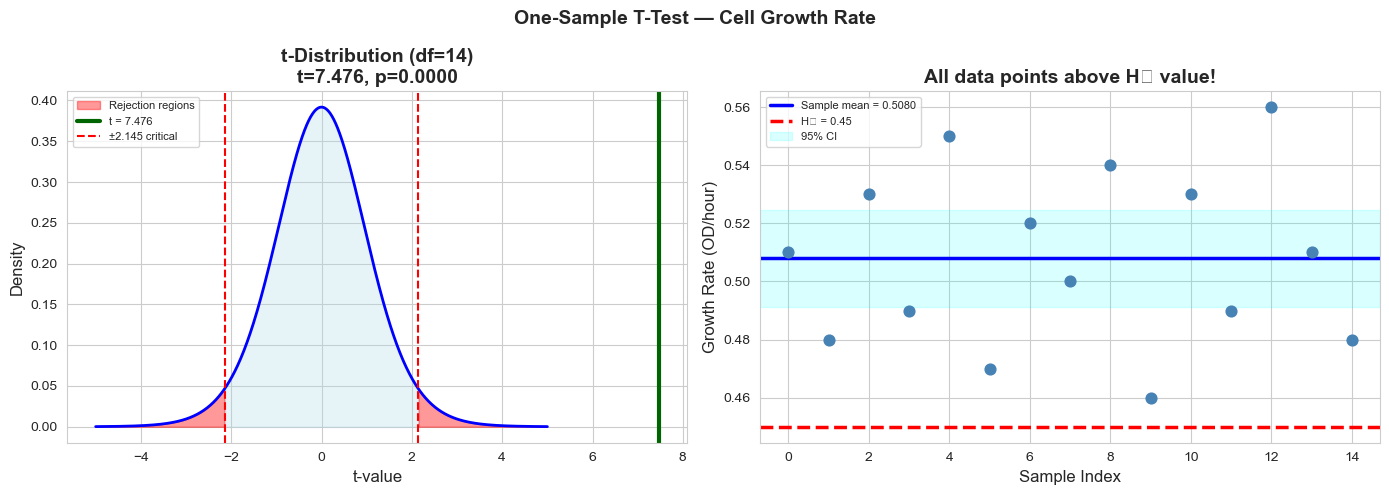

In [22]:
# Visualization: One-Sample T-Test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# t-distribution
ax = axes[0]
x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df=df)
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, y, where=(x >= t_crit_1), color='red', alpha=0.4, label='Rejection regions')
ax.fill_between(x, y, where=(x <= -t_crit_1), color='red', alpha=0.4)
ax.fill_between(x, y, where=(x >= -t_crit_1) & (x <= t_crit_1), color='lightblue', alpha=0.3)
ax.axvline(t_stat_1, color='darkgreen', linewidth=3, label=f't = {t_stat_1:.3f}')
ax.axvline(t_crit_1, color='red', linestyle='--', linewidth=1.5, label=f'±{t_crit_1:.3f} critical')
ax.axvline(-t_crit_1, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('t-value')
ax.set_ylabel('Density')
ax.set_title(f't-Distribution (df={df})\nt={t_stat_1:.3f}, p={p_value_t1:.4f}', fontweight='bold')
ax.legend(fontsize=8)

# Data visualization
ax = axes[1]
ax.scatter(range(n), growth_rates, color='steelblue', s=60, zorder=3)
ax.axhline(x_bar, color='blue', linewidth=2.5, label=f'Sample mean = {x_bar:.4f}')
ax.axhline(mu_0, color='red', linewidth=2.5, linestyle='--', label=f'H₀ = {mu_0}')
ax.axhspan(ci_low_t1, ci_high_t1, alpha=0.15, color='cyan', label=f'95% CI')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Growth Rate (OD/hour)')
ax.set_title('All data points above H₀ value!', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('One-Sample T-Test — Cell Growth Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Independent Two-Sample T-Test

Compare two **independent groups** when σ is unknown.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

(Welch's t-test — does NOT assume equal variances, safer for biomedical data)

**💊 Drug Efficacy Study:**  
Compare post-treatment cholesterol (mg/dL) for Drug A vs Drug B.  
H₀: μ_A = μ_B (no difference)

In [24]:
# INDEPENDENT TWO-SAMPLE T-TEST — Drug Efficacy

np.random.seed(99)
drug_A = np.random.normal(loc=175, scale=20, size=25)
drug_B = np.random.normal(loc=195, scale=22, size=25)

n1, n2 = len(drug_A), len(drug_B)
mean1, mean2 = np.mean(drug_A), np.mean(drug_B)
s1, s2 = np.std(drug_A, ddof=1), np.std(drug_B, ddof=1)

# Welch's t-test (scipy handles it with equal_var=False)
t_stat_2, p_value_t2 = stats.ttest_ind(drug_A, drug_B, equal_var=False)

# SE and CI for the difference
se_diff2 = np.sqrt(s1**2/n1 + s2**2/n2)
diff2 = mean1 - mean2

# Welch-Satterthwaite degrees of freedom
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit_2 = stats.t.ppf(0.975, df=df_welch)
ci_low_t2 = diff2 - t_crit_2 * se_diff2
ci_high_t2 = diff2 + t_crit_2 * se_diff2

print('INDEPENDENT T-TEST: Drug A vs Drug B Cholesterol')
print('='*55)
print(f'Drug A: n={n1}, mean={mean1:.2f}, s={s1:.2f}')
print(f'Drug B: n={n2}, mean={mean2:.2f}, s={s2:.2f}')
print()
print(f'Difference: {diff2:.2f} mg/dL')
print(f'Welch t = {t_stat_2:.4f}')
print(f'p-value   = {p_value_t2:.4f}')
print(f'95% CI for difference: ({ci_low_t2:.2f}, {ci_high_t2:.2f})')
print()
if p_value_t2 < 0.05:
    print('REJECT H₀ — Significant difference between Drug A and Drug B!')

INDEPENDENT T-TEST: Drug A vs Drug B Cholesterol
Drug A: n=25, mean=175.59, s=17.82
Drug B: n=25, mean=194.53, s=23.81

Difference: -18.93 mg/dL
Welch t = -3.1835
p-value   = 0.0027
95% CI for difference: (-30.92, -6.95)

REJECT H₀ — Significant difference between Drug A and Drug B!


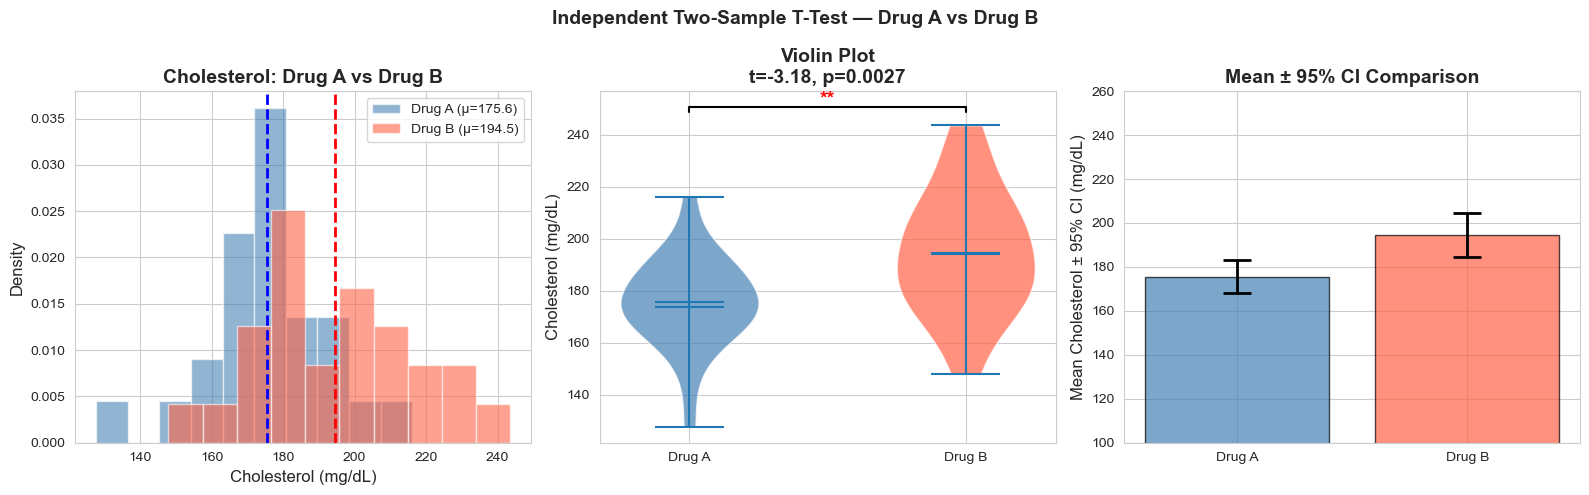

In [26]:
# Visualization: Independent T-Test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(drug_A, bins=10, alpha=0.6, color='steelblue', edgecolor='white', label=f'Drug A (μ={mean1:.1f})', density=True)
ax.hist(drug_B, bins=10, alpha=0.6, color='tomato', edgecolor='white', label=f'Drug B (μ={mean2:.1f})', density=True)
ax.axvline(mean1, color='blue', linewidth=2, linestyle='--')
ax.axvline(mean2, color='red', linewidth=2, linestyle='--')
ax.set_xlabel('Cholesterol (mg/dL)')
ax.set_ylabel('Density')
ax.set_title('Cholesterol: Drug A vs Drug B', fontweight='bold')
ax.legend()

# Violin plot
ax = axes[1]
vp = ax.violinplot([drug_A, drug_B], positions=[1, 2], showmedians=True, showmeans=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['steelblue', 'tomato'][i])
    pc.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Drug A', 'Drug B'])
ax.set_ylabel('Cholesterol (mg/dL)')
ax.set_title(f'Violin Plot\nt={t_stat_2:.2f}, p={p_value_t2:.4f}', fontweight='bold')
y_max = max(drug_A.max(), drug_B.max()) + 5
ax.plot([1, 1, 2, 2], [y_max, y_max+2, y_max+2, y_max], 'k-', linewidth=1.5)
sig_label = '***' if p_value_t2 < 0.001 else '**' if p_value_t2 < 0.01 else '*' if p_value_t2 < 0.05 else 'ns'
ax.text(1.5, y_max+3, sig_label, ha='center', fontsize=14, color='red', fontweight='bold')

# Mean ± CI bars
ax = axes[2]
means = [mean1, mean2]
errs = [stats.t.ppf(0.975, df=n1-1)*s1/np.sqrt(n1), stats.t.ppf(0.975, df=n2-1)*s2/np.sqrt(n2)]
ax.bar([1, 2], means, yerr=errs, capsize=10, color=['steelblue', 'tomato'], alpha=0.7,
       edgecolor='black', error_kw={'linewidth': 2, 'capthick': 2})
ax.set_xticks([1, 2])
ax.set_xticklabels(['Drug A', 'Drug B'])
ax.set_ylabel('Mean Cholesterol ± 95% CI (mg/dL)')
ax.set_title('Mean ± 95% CI Comparison', fontweight='bold')
ax.set_ylim(100, 260)

plt.suptitle('Independent Two-Sample T-Test — Drug A vs Drug B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Paired T-Test

Used when the **same subjects** are measured **twice** (before/after).

**Key idea:** Compute the difference for each pair → one-sample t-test on those differences vs zero.

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

Where $\bar{d}$ = mean of differences, $s_d$ = std dev of differences.

**💉 Blood Pressure Before vs After Drug:**  
- 12 patients measured before and after antihypertensive treatment
- H₀: Mean difference = 0 (drug has no effect)

In [28]:
# PAIRED T-TEST — Blood Pressure Before/After Drug

before_drug = np.array([145, 152, 138, 160, 148, 155, 143, 162, 150, 157, 141, 153])
after_drug  = np.array([132, 140, 128, 148, 137, 142, 130, 150, 139, 145, 132, 141])

# Compute differences
diffs = before_drug - after_drug   # Positive = reduction in BP (good!)
n = len(diffs)
d_bar = np.mean(diffs)
s_d = np.std(diffs, ddof=1)
se_d = s_d / np.sqrt(n)
df = n - 1

# T-statistic and p-value
t_stat_p = d_bar / se_d
p_value_p = 2 * (1 - stats.t.cdf(abs(t_stat_p), df=df))

# 95% CI for mean difference
t_crit_p = stats.t.ppf(0.975, df=df)
ci_low_p = d_bar - t_crit_p * se_d
ci_high_p = d_bar + t_crit_p * se_d

# Verify with scipy
t_sp2, p_sp2 = stats.ttest_rel(before_drug, after_drug)

print('PAIRED T-TEST: Blood Pressure Before vs After Drug')
print('='*55)
print(f'{"Patient":<12} {"Before":>8} {"After":>8} {"Diff":>8}')
print('-'*38)
for i in range(n):
    print(f'{f"Patient {i+1}":<12} {before_drug[i]:>8} {after_drug[i]:>8} {diffs[i]:>+8}')
print('-'*38)
print(f'{"Mean":<12} {np.mean(before_drug):>8.1f} {np.mean(after_drug):>8.1f} {d_bar:>+8.2f}')
print()
print(f'H₀: Mean difference = 0 | H₁: ≠ 0 (two-tailed)')
print(f'd̄ = {d_bar:.2f} mmHg, s_d = {s_d:.2f}, SE = {se_d:.4f}')
print(f't = {t_stat_p:.4f}, df = {df}')
print(f'p-value = {p_value_p:.8f}')
print(f'95% CI: ({ci_low_p:.2f}, {ci_high_p:.2f}) mmHg')
print(f'Scipy: t={t_sp2:.4f}, p={p_sp2:.8f}  [matches!]')
print()
if p_value_p < 0.05:
    print(f'REJECT H₀ — Drug reduced BP by {d_bar:.1f} mmHg on average (p << 0.05)!')

PAIRED T-TEST: Blood Pressure Before vs After Drug
Patient        Before    After     Diff
--------------------------------------
Patient 1         145      132      +13
Patient 2         152      140      +12
Patient 3         138      128      +10
Patient 4         160      148      +12
Patient 5         148      137      +11
Patient 6         155      142      +13
Patient 7         143      130      +13
Patient 8         162      150      +12
Patient 9         150      139      +11
Patient 10        157      145      +12
Patient 11        141      132       +9
Patient 12        153      141      +12
--------------------------------------
Mean            150.3    138.7   +11.67

H₀: Mean difference = 0 | H₁: ≠ 0 (two-tailed)
d̄ = 11.67 mmHg, s_d = 1.23, SE = 0.3553
t = 32.8329, df = 11
p-value = 0.00000000
95% CI: (10.88, 12.45) mmHg
Scipy: t=32.8329, p=0.00000000  [matches!]

REJECT H₀ — Drug reduced BP by 11.7 mmHg on average (p << 0.05)!


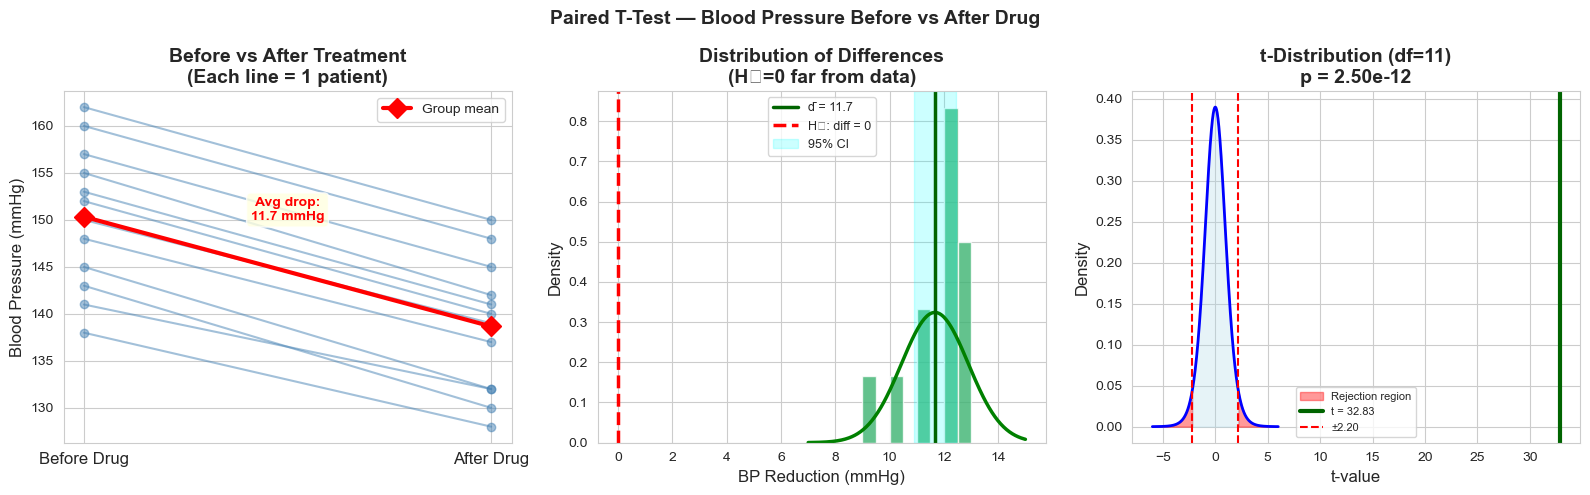

In [30]:
# Visualization: Paired T-Test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
n = len(before_drug)

# Spaghetti plot
ax = axes[0]
for i in range(n):
    ax.plot([1, 2], [before_drug[i], after_drug[i]], 'o-', color='steelblue', alpha=0.5, linewidth=1.5)
ax.plot([1, 2], [np.mean(before_drug), np.mean(after_drug)], 'D-',
        color='red', linewidth=3, markersize=10, zorder=5, label='Group mean')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Before Drug', 'After Drug'], fontsize=12)
ax.set_ylabel('Blood Pressure (mmHg)')
ax.set_title(f'Before vs After Treatment\n(Each line = 1 patient)', fontweight='bold')
ax.legend()
ax.text(1.5, 150, f'Avg drop:\n{d_bar:.1f} mmHg', ha='center', fontsize=10, color='red',
        fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Distribution of differences
ax = axes[1]
ax.hist(diffs, bins=8, color='mediumseagreen', edgecolor='white', alpha=0.8, density=True)
x_d = np.linspace(min(diffs)-2, max(diffs)+2, 300)
ax.plot(x_d, stats.norm.pdf(x_d, d_bar, s_d), 'g-', linewidth=2.5)
ax.axvline(d_bar, color='darkgreen', linewidth=2.5, label=f'd̄ = {d_bar:.1f}')
ax.axvline(0, color='red', linewidth=2.5, linestyle='--', label='H₀: diff = 0')
ax.axvspan(ci_low_p, ci_high_p, alpha=0.2, color='cyan', label='95% CI')
ax.set_xlabel('BP Reduction (mmHg)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Differences\n(H₀=0 far from data)', fontweight='bold')
ax.legend(fontsize=9)

# t-distribution
ax = axes[2]
x = np.linspace(-6, 6, 1000)
y = stats.t.pdf(x, df=df)
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, y, where=(x >= t_crit_p), color='red', alpha=0.4, label='Rejection region')
ax.fill_between(x, y, where=(x <= -t_crit_p), color='red', alpha=0.4)
ax.fill_between(x, y, where=(x >= -t_crit_p) & (x <= t_crit_p), color='lightblue', alpha=0.3)
ax.axvline(t_stat_p, color='darkgreen', linewidth=3, label=f't = {t_stat_p:.2f}')
ax.axvline(t_crit_p, color='red', linestyle='--', linewidth=1.5)
ax.axvline(-t_crit_p, color='red', linestyle='--', linewidth=1.5, label=f'±{t_crit_p:.2f}')
ax.set_xlabel('t-value')
ax.set_ylabel('Density')
ax.set_title(f't-Distribution (df={df})\np = {p_value_p:.2e}', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Paired T-Test — Blood Pressure Before vs After Drug', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Real-World Biomedical Data — Pima Indians Diabetes Dataset

The **Pima Indians Diabetes dataset** is a real biomedical dataset from the UCI ML Repository containing health measurements of Pima Indian women.  
It includes glucose, blood pressure, BMI, age, and diabetes outcome.

We'll try to download it directly; if offline, we generate realistic synthetic data from published statistics.

In [32]:
# REAL DATA: Pima Indians Diabetes Dataset
# Attempt direct download; fallback to published-statistics synthetic data

try:
    import urllib.request
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
    cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigree','Age','Outcome']
    pima = pd.read_csv(url, names=cols)
    print(f'Downloaded Pima dataset from web! Shape: {pima.shape}')
except:
    print('Offline — generating data from published Pima dataset statistics...')
    np.random.seed(2024)
    n_diabetic, n_healthy = 268, 500
    pima = pd.DataFrame({
        'Pregnancies': np.concatenate([np.random.poisson(4.9, n_diabetic), np.random.poisson(3.3, n_healthy)]),
        'Glucose': np.concatenate([
            np.random.normal(141.3, 31.9, n_diabetic).clip(50, 250),
            np.random.normal(109.9, 26.1, n_healthy).clip(50, 200)
        ]),
        'BloodPressure': np.concatenate([
            np.random.normal(70.8, 21.5, n_diabetic).clip(40, 120),
            np.random.normal(68.2, 18.1, n_healthy).clip(40, 120)
        ]),
        'BMI': np.concatenate([
            np.random.normal(35.1, 7.3, n_diabetic).clip(18, 60),
            np.random.normal(30.3, 7.8, n_healthy).clip(18, 55)
        ]),
        'Age': np.concatenate([
            np.random.normal(37.1, 10.9, n_diabetic).clip(20, 80).astype(int),
            np.random.normal(31.2, 11.6, n_healthy).clip(20, 80).astype(int)
        ]),
        'Outcome': [1]*n_diabetic + [0]*n_healthy
    }).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Synthetic Pima-like dataset created! Shape: {pima.shape}')

diabetic = pima[pima['Outcome'] == 1]
healthy  = pima[pima['Outcome'] == 0]
print(f'Diabetic: {len(diabetic)}, Non-diabetic: {len(healthy)}')
print()
print(pima[['Glucose','BloodPressure','BMI','Age','Outcome']].describe().round(2))

Downloaded Pima dataset from web! Shape: (768, 9)
Diabetic: 268, Non-diabetic: 500

       Glucose  BloodPressure     BMI     Age  Outcome
count   768.00         768.00  768.00  768.00   768.00
mean    120.89          69.11   31.99   33.24     0.35
std      31.97          19.36    7.88   11.76     0.48
min       0.00           0.00    0.00   21.00     0.00
25%      99.00          62.00   27.30   24.00     0.00
50%     117.00          72.00   32.00   29.00     0.00
75%     140.25          80.00   36.60   41.00     1.00
max     199.00         122.00   67.10   81.00     1.00


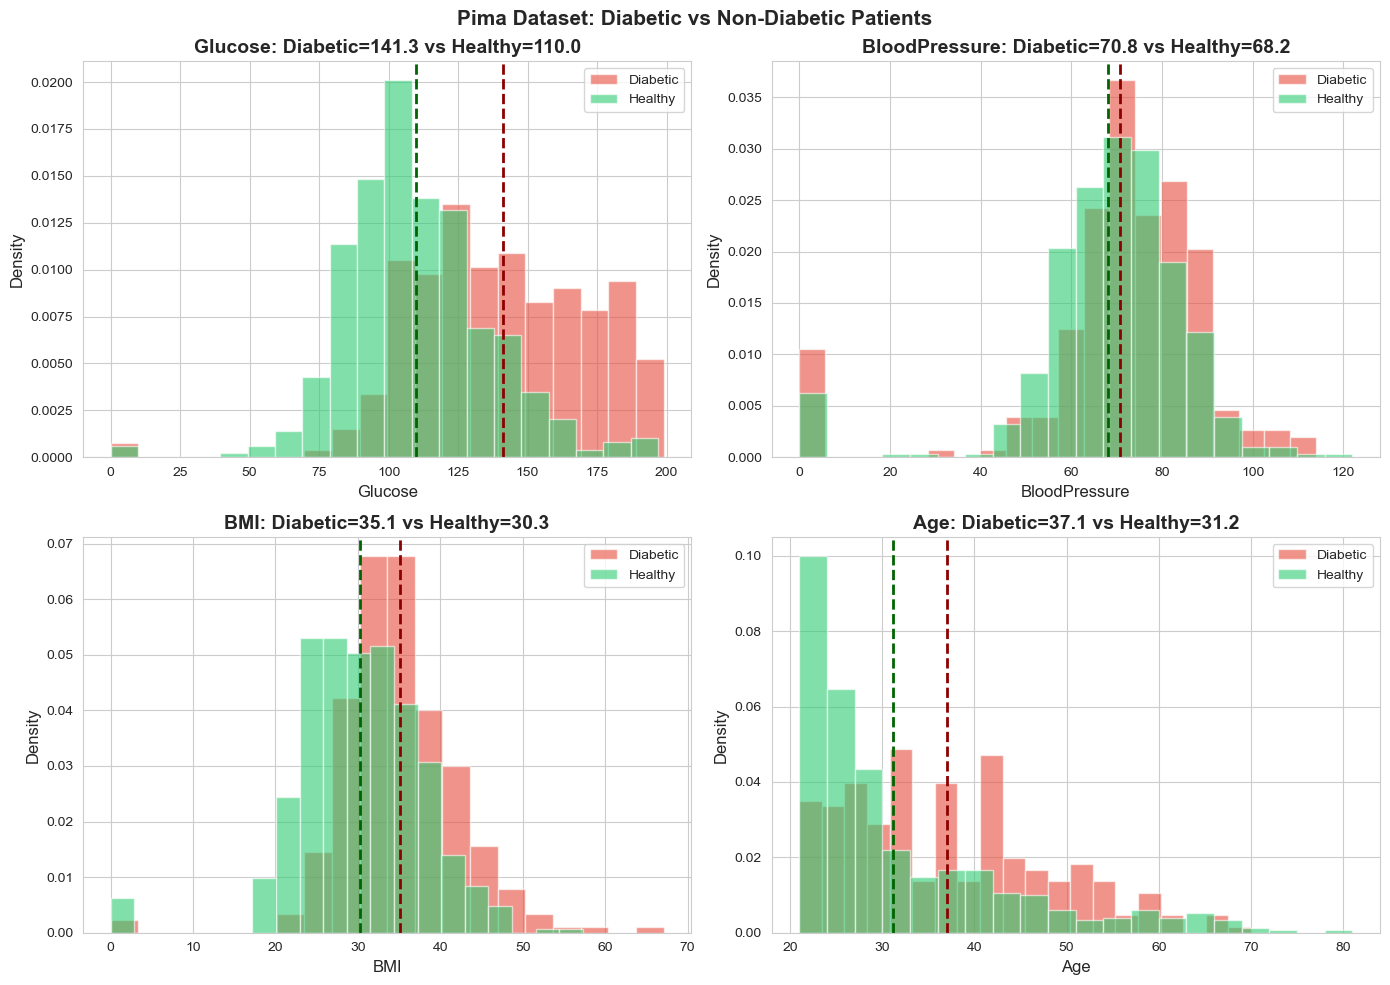

In [34]:
# Exploratory Visualization of Pima Dataset

features = ['Glucose', 'BloodPressure', 'BMI', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.hist(diabetic[feat], bins=20, alpha=0.6, color='#E74C3C', label='Diabetic', density=True, edgecolor='white')
    ax.hist(healthy[feat], bins=20, alpha=0.6, color='#2ECC71', label='Healthy', density=True, edgecolor='white')
    ax.axvline(diabetic[feat].mean(), color='darkred', linewidth=2, linestyle='--')
    ax.axvline(healthy[feat].mean(), color='darkgreen', linewidth=2, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat}: Diabetic={diabetic[feat].mean():.1f} vs Healthy={healthy[feat].mean():.1f}',
                 fontweight='bold')
    ax.legend()

plt.suptitle('Pima Dataset: Diabetic vs Non-Diabetic Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# Apply Independent T-Tests to all features

features_test = ['Glucose', 'BloodPressure', 'BMI', 'Age']

print('INDEPENDENT T-TESTS: Diabetic vs Non-Diabetic (Pima Dataset)')
print('='*80)
print(f'{"Feature":<16} {"Diabetic μ":>12} {"Healthy μ":>11} {"t-stat":>9} {"p-value":>12} {"Significant":>14}')
print('-'*75)

results = []
for feat in features_test:
    g1 = diabetic[feat].dropna()
    g2 = healthy[feat].dropna()
    t_s, p_v = stats.ttest_ind(g1, g2, equal_var=False)
    sig = 'YES ***' if p_v < 0.001 else 'YES **' if p_v < 0.01 else 'YES *' if p_v < 0.05 else 'NO'
    results.append({'feat': feat, 'dm': g1.mean(), 'hm': g2.mean(), 't': t_s, 'p': p_v})
    print(f'{feat:<16} {g1.mean():>12.2f} {g2.mean():>11.2f} {t_s:>9.3f} {p_v:>12.2e} {sig:>14}')

print()
print('Significant findings:')
for r in results:
    if r['p'] < 0.05:
        dir_word = 'HIGHER' if r['dm'] > r['hm'] else 'LOWER'
        print(f'  {r["feat"]}: Diabetic patients have significantly {dir_word} values '
              f'({r["dm"]:.1f} vs {r["hm"]:.1f}, p={r["p"]:.2e})')

INDEPENDENT T-TESTS: Diabetic vs Non-Diabetic (Pima Dataset)
Feature            Diabetic μ   Healthy μ    t-stat      p-value    Significant
---------------------------------------------------------------------------
Glucose                141.26      109.98    13.752     2.64e-36        YES ***
BloodPressure           70.82       68.18     1.713     8.74e-02             NO
BMI                     35.14       30.30     8.619     6.57e-17        YES ***
Age                     37.07       31.19     6.921     1.20e-11        YES ***

Significant findings:
  Glucose: Diabetic patients have significantly HIGHER values (141.3 vs 110.0, p=2.64e-36)
  BMI: Diabetic patients have significantly HIGHER values (35.1 vs 30.3, p=6.57e-17)
  Age: Diabetic patients have significantly HIGHER values (37.1 vs 31.2, p=1.20e-11)


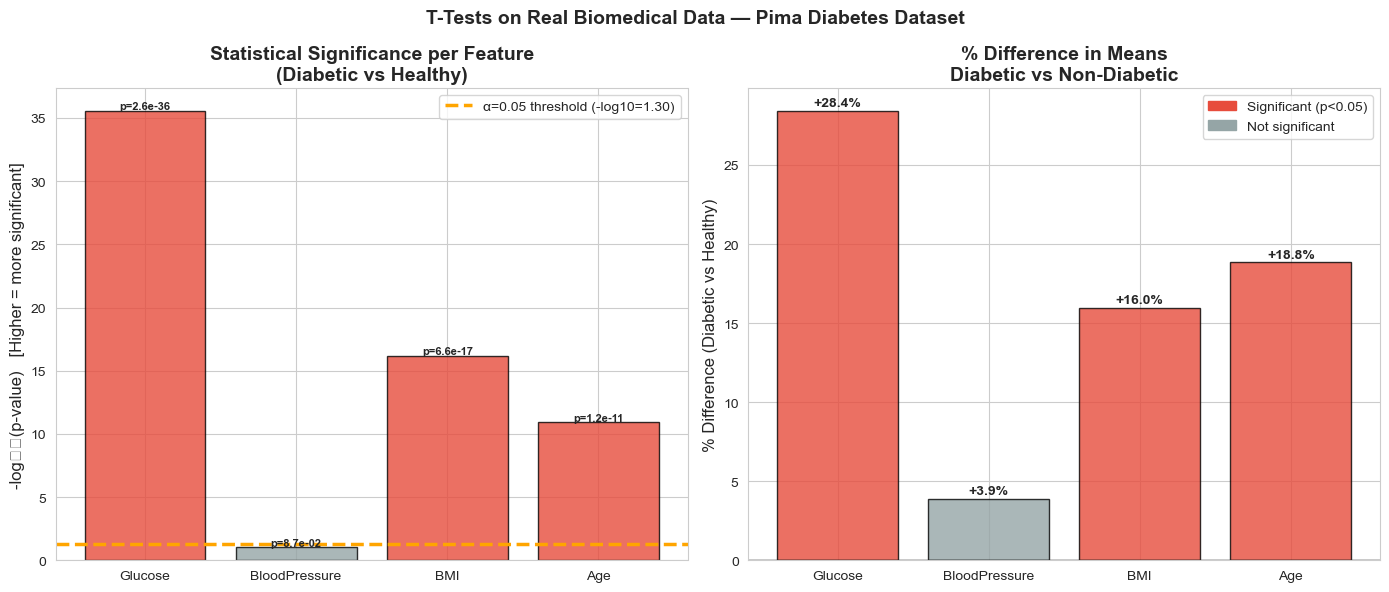

In [38]:
# Summary Visualization: Multiple T-Tests on Real Data

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# p-values bar chart
ax = axes[0]
p_vals = [r['p'] for r in results]
feats = [r['feat'] for r in results]
bar_colors = ['#E74C3C' if p < 0.05 else '#95A5A6' for p in p_vals]
bars = ax.bar(feats, [-np.log10(p) for p in p_vals], color=bar_colors, edgecolor='black', alpha=0.8)
ax.axhline(-np.log10(0.05), color='orange', linestyle='--', linewidth=2.5,
           label='α=0.05 threshold (-log10=1.30)')
ax.set_ylabel('-log₁₀(p-value)   [Higher = more significant]')
ax.set_title('Statistical Significance per Feature\n(Diabetic vs Healthy)', fontweight='bold')
ax.legend()
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'p={p:.1e}', ha='center', fontsize=8, fontweight='bold')

# % difference chart
ax = axes[1]
pct_diffs = [(r['dm'] - r['hm'])/r['hm'] * 100 for r in results]
colors2 = ['#E74C3C' if r['p'] < 0.05 else '#95A5A6' for r in results]
bars2 = ax.bar(feats, pct_diffs, color=colors2, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('% Difference (Diabetic vs Healthy)')
ax.set_title('% Difference in Means\nDiabetic vs Non-Diabetic', fontweight='bold')
for bar, pct in zip(bars2, pct_diffs):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3 if h >= 0 else h - 1.5,
            f'{pct:+.1f}%', ha='center', fontsize=10, fontweight='bold')
red_p = mpatches.Patch(color='#E74C3C', label='Significant (p<0.05)')
gray_p = mpatches.Patch(color='#95A5A6', label='Not significant')
ax.legend(handles=[red_p, gray_p])

plt.suptitle('T-Tests on Real Biomedical Data — Pima Diabetes Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Type I and Type II Errors

| | **H₀ True** | **H₀ False** |
|---|---|---|
| **Reject H₀** | Type I Error (α, False Positive) ❌ | Correct — True Positive ✅ |
| **Fail to Reject H₀** | Correct — True Negative ✅ | Type II Error (β, False Negative) ❌ |

- **Type I (α):** Saying drug works when it doesn't
- **Type II (β):** Missing a real drug effect
- **Power (1-β):** Probability of detecting a real effect

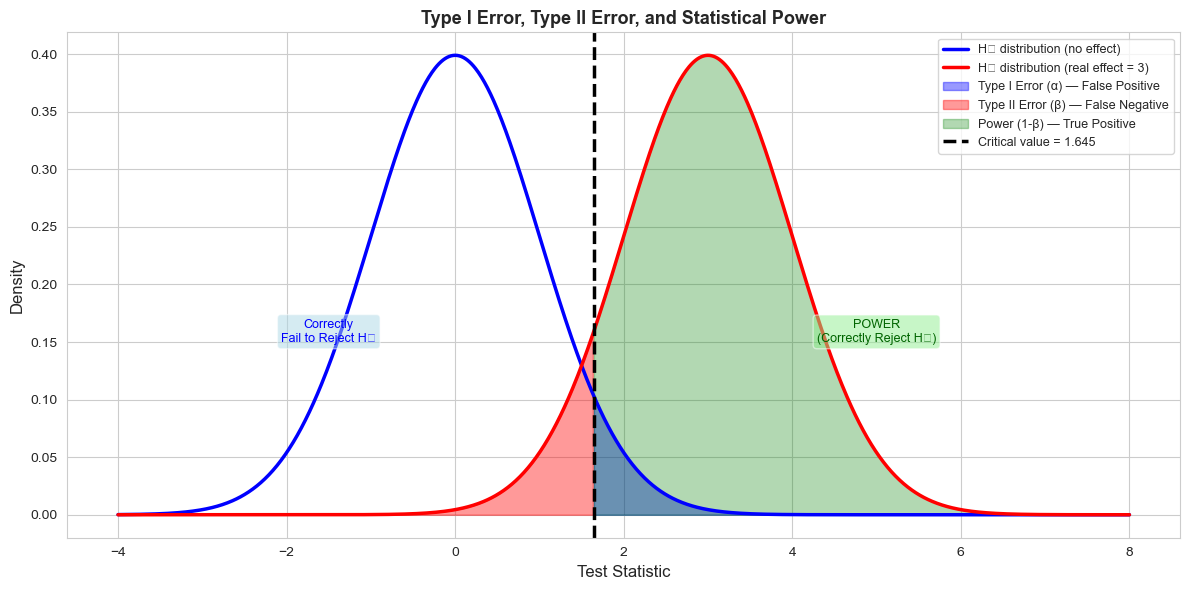

α (Type I Error rate):   0.050 (5.0%)
β (Type II Error rate):  0.088 (8.8%)
Power (1-β):             0.912 (91.2%)


In [40]:
# Type I, Type II Errors and Power Visualization

fig, ax = plt.subplots(figsize=(12, 6))
x = np.linspace(-4, 8, 1000)
dist_null = stats.norm.pdf(x, 0, 1)
dist_alt  = stats.norm.pdf(x, 3, 1)
critical_val = 1.645   # one-tailed α=0.05

ax.plot(x, dist_null, 'b-', linewidth=2.5, label='H₀ distribution (no effect)')
ax.plot(x, dist_alt, 'r-', linewidth=2.5, label='H₁ distribution (real effect = 3)')
ax.fill_between(x, dist_null, where=(x >= critical_val), color='blue', alpha=0.4, label='Type I Error (α) — False Positive')
ax.fill_between(x, dist_alt, where=(x <= critical_val), color='red', alpha=0.4, label='Type II Error (β) — False Negative')
ax.fill_between(x, dist_alt, where=(x >= critical_val), color='green', alpha=0.3, label='Power (1-β) — True Positive')
ax.axvline(critical_val, color='black', linestyle='--', linewidth=2.5, label=f'Critical value = {critical_val}')

ax.set_xlabel('Test Statistic')
ax.set_ylabel('Density')
ax.set_title('Type I Error, Type II Error, and Statistical Power', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)

ax.text(-1.5, 0.15, 'Correctly\nFail to Reject H₀', ha='center', fontsize=9, color='blue',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.text(5, 0.15, 'POWER\n(Correctly Reject H₀)', ha='center', fontsize=9, color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.tight_layout()
plt.show()

alpha_e = 1 - stats.norm.cdf(critical_val)
beta_e  = stats.norm.cdf(critical_val, loc=3)
power_e = 1 - beta_e
print(f'α (Type I Error rate):   {alpha_e:.3f} ({alpha_e*100:.1f}%)')
print(f'β (Type II Error rate):  {beta_e:.3f} ({beta_e*100:.1f}%)')
print(f'Power (1-β):             {power_e:.3f} ({power_e*100:.1f}%)')

---
## 8. Complete Summary & Key Takeaways

In [42]:
# Summary Table: All Tests

print('='*85)
print('        HYPOTHESIS TESTING SUMMARY TABLE — BIOENGINEERING APPLICATIONS')
print('='*85)
print(f'{"Test":<24} {"Scenario":<35} {"σ known":>8} {"Statistic":>12} {"p-value":>10} {"Reject H₀?":>12}')
print('-'*105)

all_tests = [
    ('One-Sample Z-Test', 'Bone density implant (n=50)', 'Yes', z_stat, 2*(1-stats.norm.cdf(abs(z_stat)))),
    ('Two-Sample Z-Test', 'Heart rate: athletes vs sed.', 'Yes', z_stat_2, 2*(1-stats.norm.cdf(abs(z_stat_2)))),
    ('One-Sample T-Test', 'Cell growth rate (n=15)', 'No', t_stat_1, p_value_t1),
    ('Independent T-Test', 'Cholesterol: Drug A vs B', 'No', t_stat_2, p_value_t2),
    ('Paired T-Test', 'BP before/after drug (n=12)', 'No', t_stat_p, p_value_p),
]

for test, scenario, known, stat, p in all_tests:
    stat_label = f'Z={stat:.3f}' if 'Z-Test' in test else f't={stat:.3f}'
    reject = 'YES ✅' if p < 0.05 else 'NO ❌'
    print(f'{test:<24} {scenario:<35} {known:>8} {stat_label:>12} {p:>10.4f} {reject:>12}')

print()
print('KEY TAKEAWAYS:')
print('  1. p < 0.05 → Reject H₀ (statistically significant result)')
print('  2. p-value ≠ probability that H₀ is true')
print('  3. Z-test: use when σ is KNOWN and n >= 30')
print('  4. T-test: use when σ is UNKNOWN (most real bioengineering cases)')
print('  5. Paired t-test: same subjects measured twice (before/after)')
print('  6. CI not containing null value ↔ p-value < α (they agree!)')
print('  7. Statistical significance ≠ Clinical/practical significance')

        HYPOTHESIS TESTING SUMMARY TABLE — BIOENGINEERING APPLICATIONS
Test                     Scenario                             σ known    Statistic    p-value   Reject H₀?
---------------------------------------------------------------------------------------------------------
One-Sample Z-Test        Bone density implant (n=50)              Yes     Z=-4.246     0.0000        YES ✅
Two-Sample Z-Test        Heart rate: athletes vs sed.             Yes     Z=-6.946     0.0000        YES ✅
One-Sample T-Test        Cell growth rate (n=15)                   No      t=7.476     0.0000        YES ✅
Independent T-Test       Cholesterol: Drug A vs B                  No     t=-3.183     0.0027        YES ✅
Paired T-Test            BP before/after drug (n=12)               No     t=32.833     0.0000        YES ✅

KEY TAKEAWAYS:
  1. p < 0.05 → Reject H₀ (statistically significant result)
  2. p-value ≠ probability that H₀ is true
  3. Z-test: use when σ is KNOWN and n >= 30
  4. T-test: use

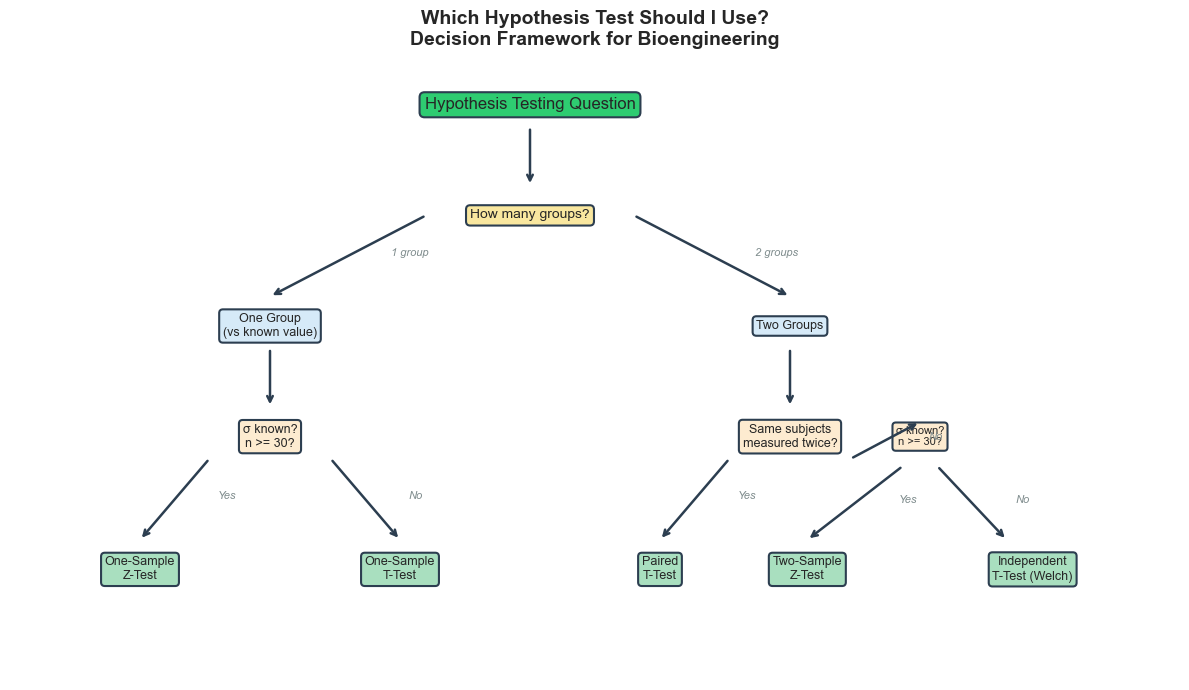

Congratulations! You have completed the Hypothesis Testing for Bioengineering tutorial!


In [44]:
# Final Visual: Decision Guide

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

def box(ax, x, y, txt, color='#D6EAF8', fs=9):
    ax.text(x, y, txt, ha='center', va='center', fontsize=fs,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='#2C3E50', linewidth=1.5),
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.8))
    if label:
        ax.text((x1+x2)/2+0.05, (y1+y2)/2, label, fontsize=8, color='#7F8C8D', fontstyle='italic')

box(ax, 0.5, 0.93, 'Hypothesis Testing Question', '#2ECC71', fs=12)
box(ax, 0.5, 0.78, 'How many groups?', '#F9E79F', fs=10)
arrow(ax, 0.5, 0.90, 0.5, 0.82)

box(ax, 0.2, 0.63, 'One Group\n(vs known value)', '#D6EAF8')
box(ax, 0.8, 0.63, 'Two Groups', '#D6EAF8')
arrow(ax, 0.38, 0.78, 0.2, 0.67, '1 group')
arrow(ax, 0.62, 0.78, 0.8, 0.67, '2 groups')

box(ax, 0.2, 0.48, 'σ known?\nn >= 30?', '#FDEBD0')
arrow(ax, 0.2, 0.60, 0.2, 0.52)

box(ax, 0.8, 0.48, 'Same subjects\nmeasured twice?', '#FDEBD0')
arrow(ax, 0.8, 0.60, 0.8, 0.52)

box(ax, 0.05, 0.30, 'One-Sample\nZ-Test', '#A9DFBF', fs=9)
box(ax, 0.35, 0.30, 'One-Sample\nT-Test', '#A9DFBF', fs=9)
arrow(ax, 0.13, 0.45, 0.05, 0.34, 'Yes')
arrow(ax, 0.27, 0.45, 0.35, 0.34, 'No')

box(ax, 0.65, 0.30, 'Paired\nT-Test', '#A9DFBF', fs=9)
box(ax, 0.95, 0.48, 'σ known?\nn >= 30?', '#FDEBD0', fs=8)
arrow(ax, 0.73, 0.45, 0.65, 0.34, 'Yes')
arrow(ax, 0.87, 0.45, 0.95, 0.50, 'No')

box(ax, 0.82, 0.30, 'Two-Sample\nZ-Test', '#A9DFBF', fs=9)
box(ax, 1.08, 0.30, 'Independent\nT-Test (Welch)', '#A9DFBF', fs=9)
arrow(ax, 0.93, 0.44, 0.82, 0.34, 'Yes')
arrow(ax, 0.97, 0.44, 1.05, 0.34, 'No')

ax.set_xlim(-0.1, 1.25)
ax.set_ylim(0.15, 1.0)
ax.set_title('Which Hypothesis Test Should I Use?\nDecision Framework for Bioengineering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Congratulations! You have completed the Hypothesis Testing for Bioengineering tutorial!')